# Notebook 9 – Data Transformation
## Why Transform Data?

Many models (Linear Regression, Logistic Regression, and anything based on
distance or normality assumptions) perform better when features roughly
follow a normal, bell-shaped distribution. Real data rarely cooperates.

`MonthlyIncome` in this dataset has a skewness of **8.3**, meaning it's
heavily right-skewed: most employees cluster in a lower range, then a long
tail of high earners stretches the distribution out. Transformation
reshapes this without changing which employee earns more than another.

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import skew

df = pd.read_csv("hr_employee_attrition_raw.csv")
df["MonthlyIncome_clean"] = pd.to_numeric(
    df["MonthlyIncome"].astype(str).str.replace(" USD", "", regex=False).str.strip(),
    errors="coerce"
)

income = df["MonthlyIncome_clean"].dropna()
income = income[income > 0]

print("Skewness before any transformation:", round(skew(income), 3))

Skewness before any transformation: 8.317


## Log Transformation

**Formula:** `log(x)` or `log(1 + x)` (the `1+` handles zeros safely).

**What it does:** compresses large values much more than small ones,
pulling in the long right tail without touching the low end much.

**Result on our data:** skewness drops from **8.3 to -0.4**, close to
symmetric. This is the most common go-to for income, price, or count data
that's right-skewed.

In [2]:
income_log = np.log1p(income)
print("Skewness after log transform:", round(skew(income_log), 3))

Skewness after log transform: -0.398


## Square Root Transformation

**Formula:** `sqrt(x)`

**What it does:** also compresses large values, but more gently than log.
Useful for moderately skewed data, especially count data, where log might
over-correct.

**Result on our data:** skewness only drops from **8.3 to 2.6**. Still
quite skewed, meaning square root is too weak a fix for how extreme this
particular distribution is.

In [3]:
income_sqrt = np.sqrt(income)
print("Skewness after square root transform:", round(skew(income_sqrt), 3))

Skewness after square root transform: 2.598


## Power Transformation

**What it does:** a general family of transformations (log and square root
are actually special cases of this family) that raises values to some power,
where the power itself can be tuned to best fit the data rather than
guessed manually.

This is where **Box-Cox** and **Yeo-Johnson** come in, they're both power
transformations that automatically find the best power (called lambda) for
your specific data.

## Box-Cox Transformation

**What it does:** automatically searches for the optimal lambda value to
make the data as close to normally distributed as possible.

**Important constraint:** Box-Cox only works on strictly **positive**
values (no zeros, no negatives). Since `MonthlyIncome` is always positive,
it's a valid candidate here.

**Result on our data:** skewness drops from **8.3 to 0.075**, almost
perfectly symmetric, better than either log or square root alone, because
it's finding the mathematically best-fitting power rather than a fixed one.

In [4]:
from scipy.stats import boxcox

income_boxcox, best_lambda = boxcox(income)
print("Best lambda found:", round(best_lambda, 3))
print("Skewness after Box-Cox transform:", round(skew(income_boxcox), 3))

Best lambda found: 0.118
Skewness after Box-Cox transform: 0.075


## Yeo-Johnson Transformation

**What it does:** works like Box-Cox, but handles **zero and negative**
values too, which Box-Cox cannot.

**When to use it over Box-Cox:** any column that could contain zero or
negative numbers. `DistanceFromHomeKM` is always positive here, so Box-Cox
would technically work, but if you ever had a column like "change in
income" (which can go negative), Yeo-Johnson is the only valid option
between the two.

In [5]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method="yeo-johnson")
distance = df[["DistanceFromHomeKM"]].dropna()
distance_yj = pt.fit_transform(distance)

print("Skewness before:", round(skew(distance["DistanceFromHomeKM"]), 3))
print("Skewness after Yeo-Johnson:", round(skew(distance_yj.flatten()), 3))

Skewness before: 14.191
Skewness after Yeo-Johnson: 0.002


## Handling Skewed Data — Choosing the Right Transform

A simple decision path based on what we just saw:

* Mildly skewed, all positive values: try **square root** first.
* Strongly skewed (like our income column, skew = 8.3), all positive
  values: use **log transform** or **Box-Cox**.
* Data includes zero or negative values: use **Yeo-Johnson**, since log
  and Box-Cox will error out or need awkward workarounds.
* Not sure which fits best: let Box-Cox or Yeo-Johnson search for the
  optimal lambda automatically, rather than guessing.

## Normalization and Standardization, Revisited

Transformation and scaling solve different problems, and it's worth
being clear about the difference:

* **Transformation** (log, sqrt, Box-Cox, Yeo-Johnson) changes the
  **shape** of the distribution, fixing skewness.
* **Normalization/Standardization** (covered in Notebook 8) changes the
  **scale** of the values, fixing magnitude differences between columns.

In practice, they're often used together: transform first to fix skewness,
then scale to put the transformed values on a comparable range.

In [6]:
from sklearn.preprocessing import StandardScaler

# Transform first (fix shape), then scale (fix magnitude)
income_log_scaled = StandardScaler().fit_transform(income_log.values.reshape(-1, 1))
print("Skewness after log transform + standardization:", round(skew(income_log_scaled.flatten()), 3))

Skewness after log transform + standardization: -0.398


## Before vs After — Visual Comparison

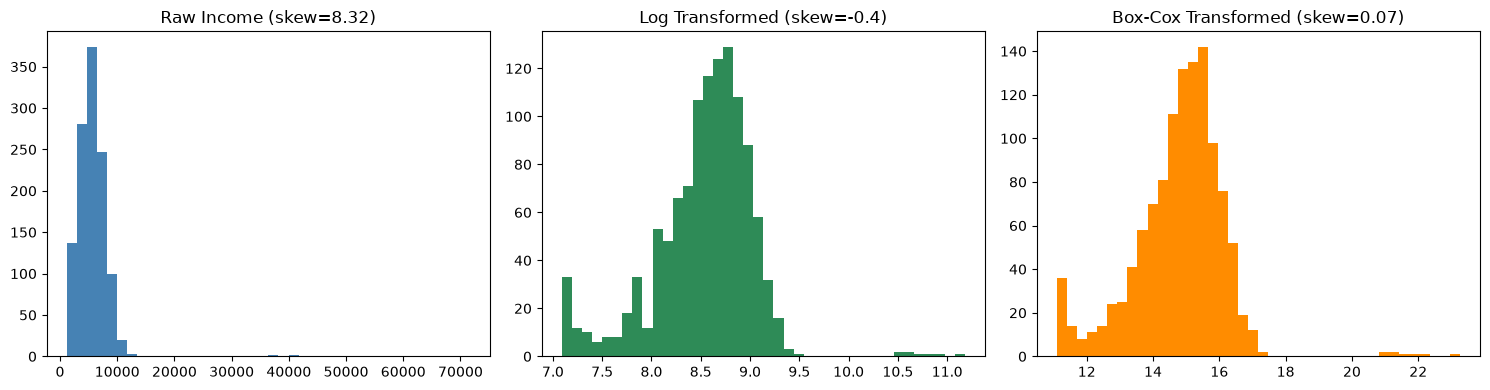

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(income, bins=40, color="steelblue")
axes[0].set_title(f"Raw Income (skew={round(skew(income), 2)})")

axes[1].hist(income_log, bins=40, color="seagreen")
axes[1].set_title(f"Log Transformed (skew={round(skew(income_log), 2)})")

axes[2].hist(income_boxcox, bins=40, color="darkorange")
axes[2].set_title(f"Box-Cox Transformed (skew={round(skew(income_boxcox), 2)})")

plt.tight_layout()
plt.show()